## Feature Engineering: Tabla RFM por cliente

### Por: Grupo 12 - ITBA
### Fecha: 2026-03-18

### Descripcion:
Construccion de la tabla RFM (Recency, Frequency, Monetary) por cliente a partir de la base limpia de ventas. Esta tabla es la base para la segmentacion por clustering.

## Importar librerias

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## Cargar datos limpios

In [2]:
df = pd.read_parquet("../../data/03_primary/ventas_limpias.parquet")
print(f"Registros: {len(df):,}")
print(f"Clientes: {df['CustomerID'].nunique():,}")
print(f"Periodo: {df['InvoiceDate'].min().date()} a {df['InvoiceDate'].max().date()}")

Registros: 397,884
Clientes: 4,338
Periodo: 2010-12-01 a 2011-12-09


## Calcular RFM

- **Recency**: dias desde la ultima compra del cliente hasta la fecha de referencia
- **Frequency**: cantidad de transacciones (invoices) unicas del cliente
- **Monetary**: revenue total del cliente

La fecha de referencia es el dia siguiente a la ultima transaccion del dataset.

In [3]:
ref_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Fecha de referencia: {ref_date.date()}")

rfm = (
    df.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (ref_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum"),
    )
    .reset_index()
)

print(f"\nTabla RFM: {len(rfm):,} clientes")
rfm.describe()

Fecha de referencia: 2011-12-10

Tabla RFM: 4,338 clientes


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


In [4]:
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


## Distribucion de cada variable RFM

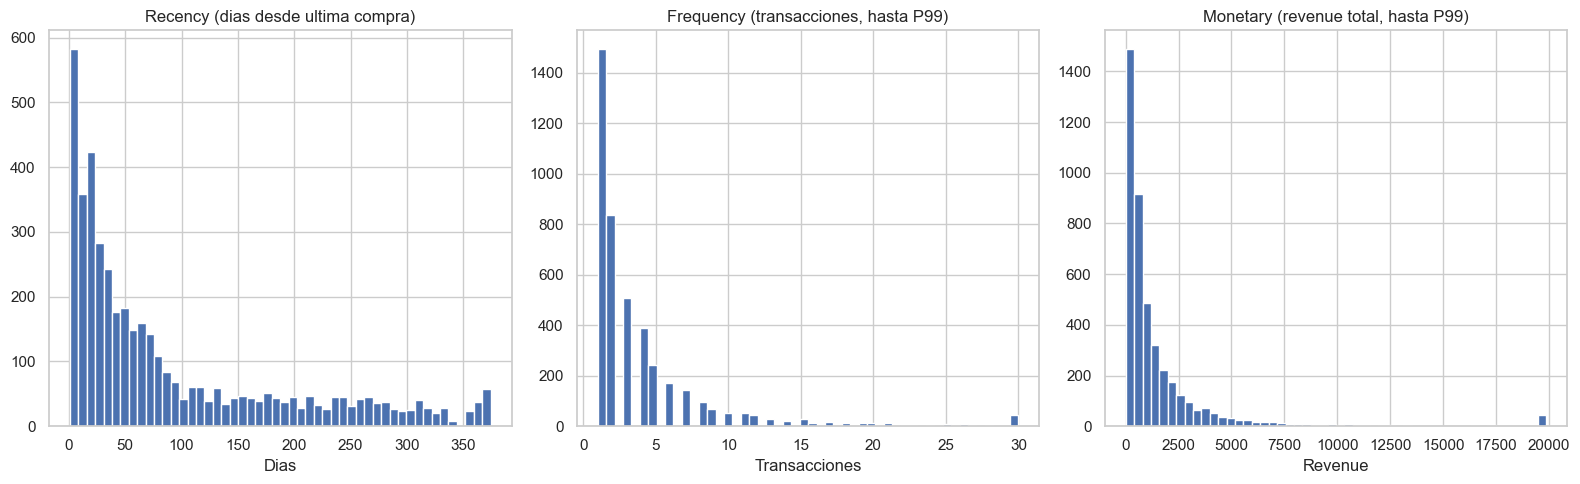

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

rfm["Recency"].hist(bins=50, ax=axes[0], edgecolor="white")
axes[0].set_title("Recency (dias desde ultima compra)")
axes[0].set_xlabel("Dias")

rfm["Frequency"].clip(upper=rfm["Frequency"].quantile(0.99)).hist(
    bins=50, ax=axes[1], edgecolor="white"
)
axes[1].set_title("Frequency (transacciones, hasta P99)")
axes[1].set_xlabel("Transacciones")

rfm["Monetary"].clip(upper=rfm["Monetary"].quantile(0.99)).hist(
    bins=50, ax=axes[2], edgecolor="white"
)
axes[2].set_title("Monetary (revenue total, hasta P99)")
axes[2].set_xlabel("Revenue")

plt.tight_layout()
plt.savefig("../../data/08_reporting/rfm_distribuciones.png", dpi=150, bbox_inches="tight")
plt.show()

## Correlacion entre variables RFM

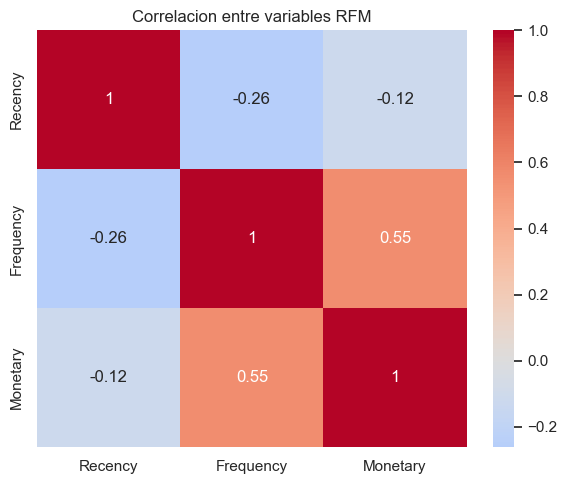

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    rfm[["Recency", "Frequency", "Monetary"]].corr(), annot=True, cmap="coolwarm", center=0, ax=ax
)
ax.set_title("Correlacion entre variables RFM")
plt.tight_layout()
plt.savefig("../../data/08_reporting/rfm_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

## Scatter plots RFM

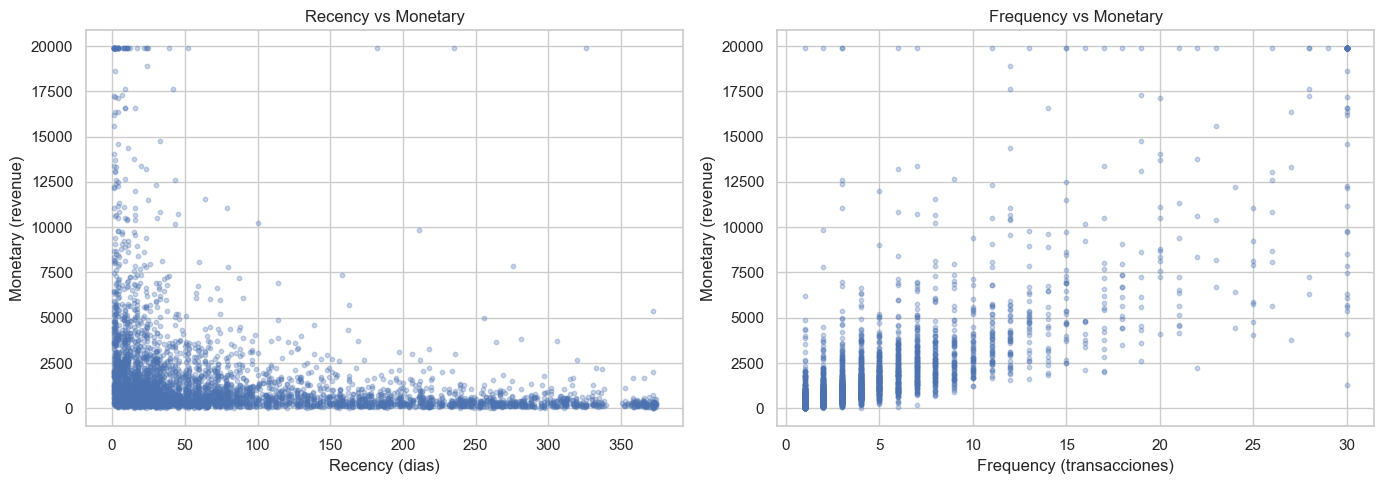

In [7]:
rfm_clipped = rfm.copy()
rfm_clipped["Frequency"] = rfm_clipped["Frequency"].clip(
    upper=rfm_clipped["Frequency"].quantile(0.99)
)
rfm_clipped["Monetary"] = rfm_clipped["Monetary"].clip(upper=rfm_clipped["Monetary"].quantile(0.99))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(rfm_clipped["Recency"], rfm_clipped["Monetary"], alpha=0.3, s=10)
axes[0].set_title("Recency vs Monetary")
axes[0].set_xlabel("Recency (dias)")
axes[0].set_ylabel("Monetary (revenue)")

axes[1].scatter(rfm_clipped["Frequency"], rfm_clipped["Monetary"], alpha=0.3, s=10)
axes[1].set_title("Frequency vs Monetary")
axes[1].set_xlabel("Frequency (transacciones)")
axes[1].set_ylabel("Monetary (revenue)")

plt.tight_layout()
plt.savefig("../../data/08_reporting/rfm_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## Guardar tabla RFM

In [8]:
FEATURE_PATH = Path("../../data/04_feature/")
FEATURE_PATH.mkdir(parents=True, exist_ok=True)

rfm.to_parquet(FEATURE_PATH / "rfm_clientes.parquet", index=False)
print(f"Tabla RFM guardada: {len(rfm):,} clientes")
print("Archivo: data/04_feature/rfm_clientes.parquet")

Tabla RFM guardada: 4,338 clientes
Archivo: data/04_feature/rfm_clientes.parquet


## Resultados y conclusiones

- Se construyo una tabla RFM con ~4,300 clientes.
- **Recency** tiene una distribucion dispersa: hay clientes que compraron recientemente y otros que no compran hace meses.
- **Frequency** esta muy sesgada: la mayoria compro pocas veces, pero hay clientes con muchas transacciones.
- **Monetary** tambien esta sesgada: pocos clientes concentran mucho revenue (coherente con el analisis Pareto del EDA).
- Frequency y Monetary tienen alta correlacion positiva (quien compra mas seguido, gasta mas).
- Recency tiene correlacion negativa con ambas (clientes recientes tienden a ser mas activos).

### Proximos pasos
- Escalar las variables RFM y aplicar clustering (K-Means, etc.) para identificar segmentos de clientes.